# N2 · ablation: 找最小必要子集

> 配套 12.3-L3 · patching 找「充分」(patch 它就恢复); ablation 找「必要」(去它就坏)。
> 对每个 (层,位置) 置零激活, 测对答案的损害。配合 N1 的 patching = **充要**因果证据。

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import patching as pt
import tiny_transformer as tt
import numpy as np, torch
torch.manual_seed(0)
Xi,Yi=tt.make_data(2000,seed=0)
model=tt.build_model(); tt.train(model,Xi,Yi,epochs=800)
print('就绪')

就绪


## 1. ablation 损害热图 (置零各位置, 看答案 logit 掉多少)

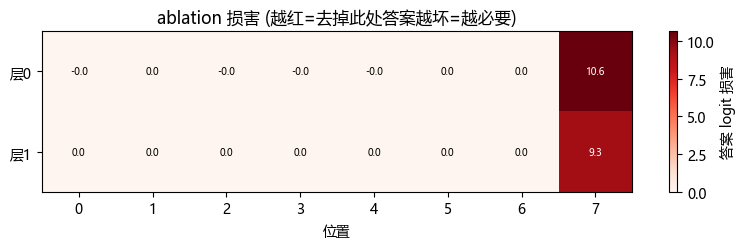

→ 损害最大 = 层0 位置7 (去掉它答案最坏 = 最必要)。


In [2]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
dmg = pt.ablate_effect(model, seed=3)
fig, ax = plt.subplots(figsize=(8,2.6))
im = ax.imshow(dmg, cmap='Reds', aspect='auto')
ax.set_yticks(range(tt.N_LAYERS)); ax.set_yticklabels([f'层{L}' for L in range(tt.N_LAYERS)])
ax.set_xticks(range(tt.SEQ)); ax.set_xlabel('位置'); ax.set_title('ablation 损害 (越红=去掉此处答案越坏=越必要)')
for L in range(tt.N_LAYERS):
    for p in range(tt.SEQ):
        ax.text(p, L, f'{dmg[L,p]:.1f}', ha='center', va='center', fontsize=7,
                color='white' if dmg[L,p]>dmg.max()*0.5 else 'black')
plt.colorbar(im, label='答案 logit 损害'); plt.tight_layout(); plt.show()
worst = np.unravel_index(np.argmax(dmg), dmg.shape)
print(f'→ 损害最大 = 层{worst[0]} 位置{worst[1]} (去掉它答案最坏 = 最必要)。')

## 2. 充分 (patching) + 必要 (ablation) = 充要因果

In [3]:
grid, _ = pt.patch_recovery(model, seed=3)
patch_best = np.unravel_index(np.argmax(grid), grid.shape)
abl_best = np.unravel_index(np.argmax(pt.ablate_effect(model, seed=3)), pt.ablate_effect(model, seed=3).shape)
print(f'patching (充分): 最能恢复 = 位置 {patch_best[1]}')
print(f'ablation (必要): 最必要   = 位置 {abl_best[1]}')
print(f'两者{"都指向同一位置 → 充要因果证据 (强)" if patch_best[1]==abl_best[1] else "不一致 → 需进一步分析"}')
print('''
证据强度 (L3):
  相关 (探针)        弱  ← 可能旁路
  充分 (patching)    中  ← patch它就恢复
  必要 (ablation)    中  ← 去它就坏
  充要 (两者都指向)  强  ← 严谨的因果定位''')

patching (充分): 最能恢复 = 位置 7
ablation (必要): 最必要   = 位置 7
两者都指向同一位置 → 充要因果证据 (强)

证据强度 (L3):
  相关 (探针)        弱  ← 可能旁路
  充分 (patching)    中  ← patch它就恢复
  必要 (ablation)    中  ← 去它就坏
  充要 (两者都指向)  强  ← 严谨的因果定位


## 3. 反思 (12.3 收口)

你用 patching (充分) + ablation (必要) 做了**充要**因果定位。带走:
- **ablation**: 删激活看损害; 损害大=必要组件 (用 mean/resample 比 zero 更可信, L4)。
- **充要论证**: patching 找充分 + ablation 找必要, 两者指向同一处 = 强因果证据。
- **严谨性是命门** (L4): 单变量/对照/度量/分布内/多样本; 否则是电路占星术。

> **M12.3 收口**: 相关→必须干预; patching 因果定位 (充分); ablation 找必要; 充要双验证; 干预=消融极致 (接 M9.4)。
> **交棒 M12.4「sparse-autoencoders」**: 回到 superposition — SAE 把叠加的多义神经元**解叠加**成单义特征 (Anthropic 显微镜)。下一专题 `sparse-autoencoders`。